## CARGAR DATASET

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [2]:
import shutil

shutil.copy(
    f"{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv",
    "./TelcoCustomerChurn.csv"
)

'./TelcoCustomerChurn.csv'

## IMPORTACION DE LIBRERIAS

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('TelcoCustomerChurn.csv')
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (7043, 21)


## EDA Análisis Exploratorio de Datos

### Vista general

C:\Users\User\AppData\Local\Temp\ipykernel_47588\343925147.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


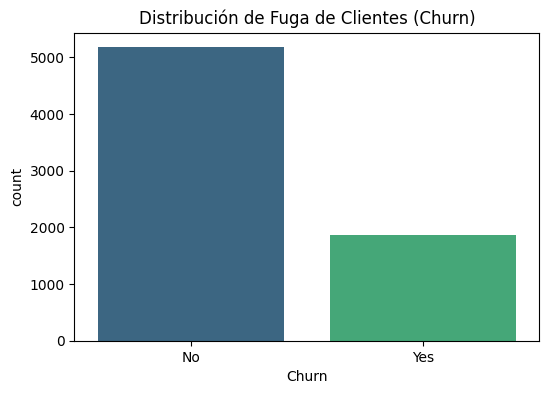

In [5]:
# Visualizar la distribución de 'Churn' (Nuestra variable objetivo 'y')
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de Fuga de Clientes (Churn)')
plt.show()

### *Diagnóstico*

In [6]:
# Verificar tipos de datos y valores nulos por columna
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

La columna 'TotalCharges' parece numérica pero viene como objeto (texto)
Se puede forzar la conversión y detectar espacios vacíos

In [7]:
# Conversión
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Contar los nulos
print(f"\nValores nulos encontrados en TotalCharges: {df['TotalCharges'].isnull().sum()}")


Valores nulos encontrados en TotalCharges: 11


In [8]:
# mask = df['TotalCharges'].isnull()
# print(df.loc[mask, 'TotalCharges'])

### *Estadísticas de las variables numéricas*


In [8]:
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7032.000000
mean     32.371149       64.761692   2283.300441
std      24.559481       30.090047   2266.771362
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3794.737500
max      72.000000      118.750000   8684.800000


### *¿Influye la permanencia y el costo mensual en la fuga?*

C:\Users\User\AppData\Local\Temp\ipykernel_47588\2465850023.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='magma')
C:\Users\User\AppData\Local\Temp\ipykernel_47588\2465850023.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='magma')


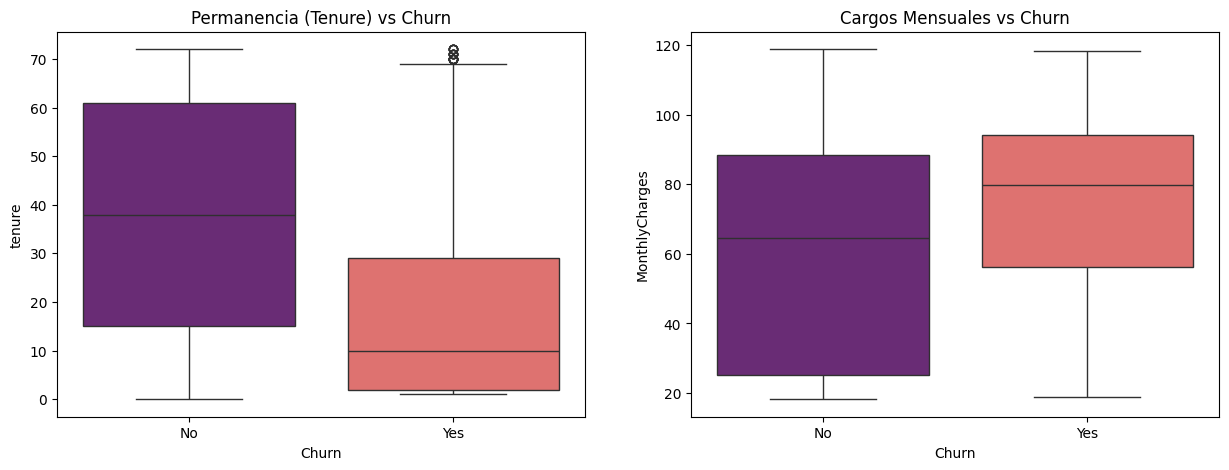

In [9]:
# Configuración de gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='magma')
axes[0].set_title('Permanencia (Tenure) vs Churn')

# MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Cargos Mensuales vs Churn')

plt.show()

Dado que el tipo de contrato es decisivo para el cliente
### *Churn X Tipo de Contrato*

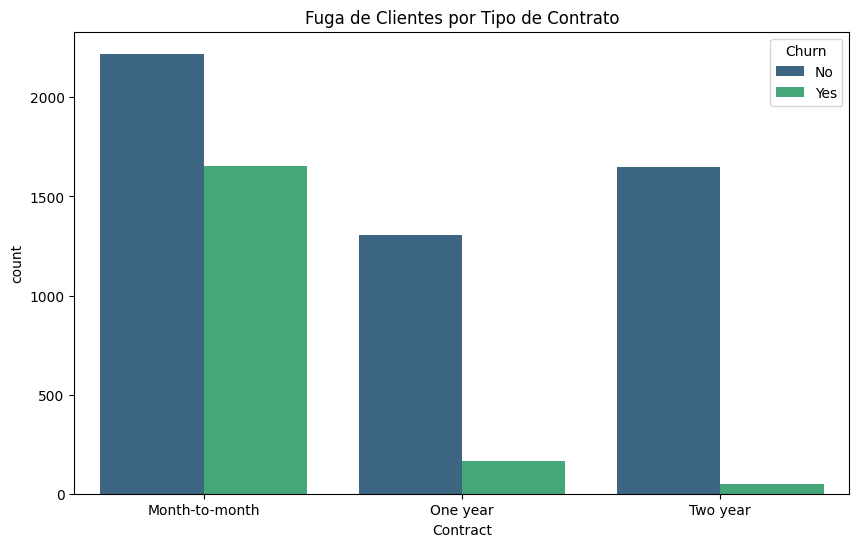

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Fuga de Clientes por Tipo de Contrato')
plt.show()

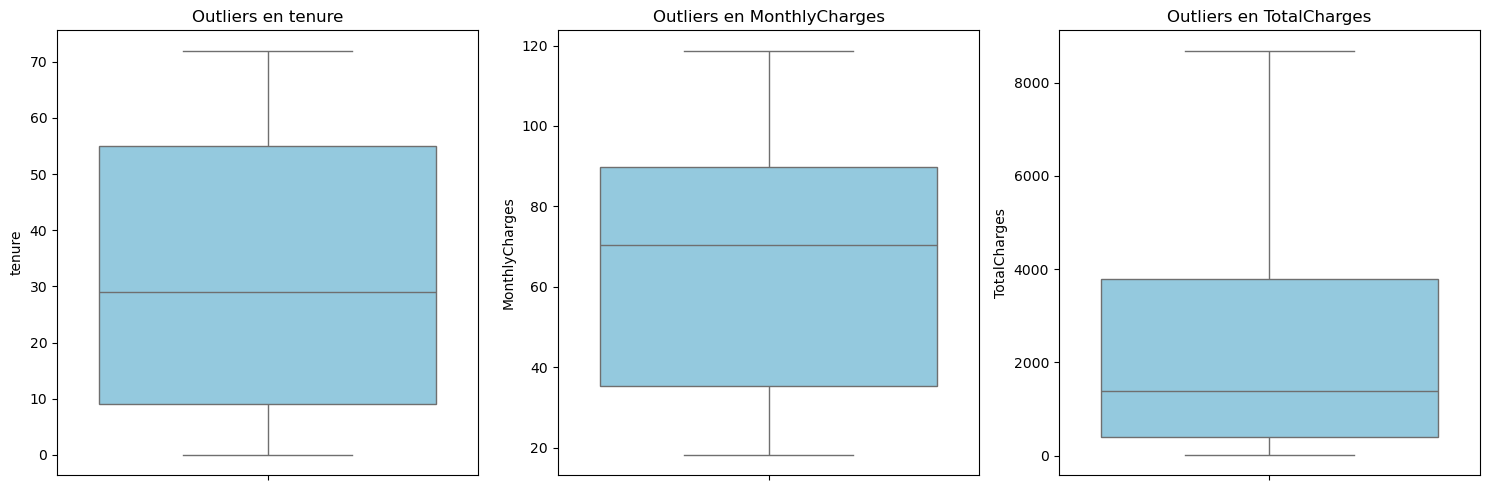

In [12]:
# Lista de variables numéricas
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 5))

for i, col in enumerate(num_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers en {col}')

plt.tight_layout()
plt.show()

## LIMPIEZA
No hay outlliers que demuestren ruido estadístico

Los valores nulos de TotalCharges, como son pocos (11), los eliminamos para no sesgar el modelo

In [11]:
df.dropna(inplace=True)

In [12]:
# Eliminar columnas que no aportan valor predictivo (ID de cliente)
df.drop(columns=['customerID'], inplace=True)

### *Copia de seguridad del dataframe procesado*

In [13]:
df.to_csv("telco_clean.csv", index=False)

df_proc = df.copy()

## MODIFICACIÓN DE FEATURES

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [15]:
# Convertir variables binarias (Yes/No) a 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_proc[col] = df_proc[col].map({'Yes': 1, 'No': 0})

In [16]:
# Convertir el género
df_proc['gender'] = df_proc['gender'].map({'Male': 1, 'Female': 0})

#### Reemplazar "No phone service" por "No" en MultipleLines 
Debido a que si no tiene PhoneService no tendrá MultipleLines (redundancia)

In [17]:
df_proc['MultipleLines'] = df_proc['MultipleLines'].replace('No phone service', 'No')

#### Reemplazar "No internet service" por "No" en MultipleLines 
Estas variables dependen estructuralmente de InternetService:

* OnlineSecurity
* OnlineBackup
* DeviceProtection
* TechSupport
* StreamingTV
* StreamingMovies

In [18]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for service in services:
    df_proc[service] = df_proc[service].replace('No internet service', 'No')

#### Convertir nuevas variables binarias (Yes/No) a 0/1


In [19]:
binary_cols = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in binary_cols:
    df_proc[col] = df_proc[col].map({'Yes': 1, 'No': 0})

#### One-Hot Encoding

In [20]:
df_proc=pd.get_dummies(df_proc, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

#### Convertir los dummies booleanos a valores enteros (True/Flase) a (0/1)

In [21]:
bool_cols = df_proc.select_dtypes(include='bool').columns
df_proc[bool_cols] = df_proc[bool_cols].astype(int)

In [22]:
df_proc.to_csv("telco_proc.csv", index=False)

### Matriz de Correlación

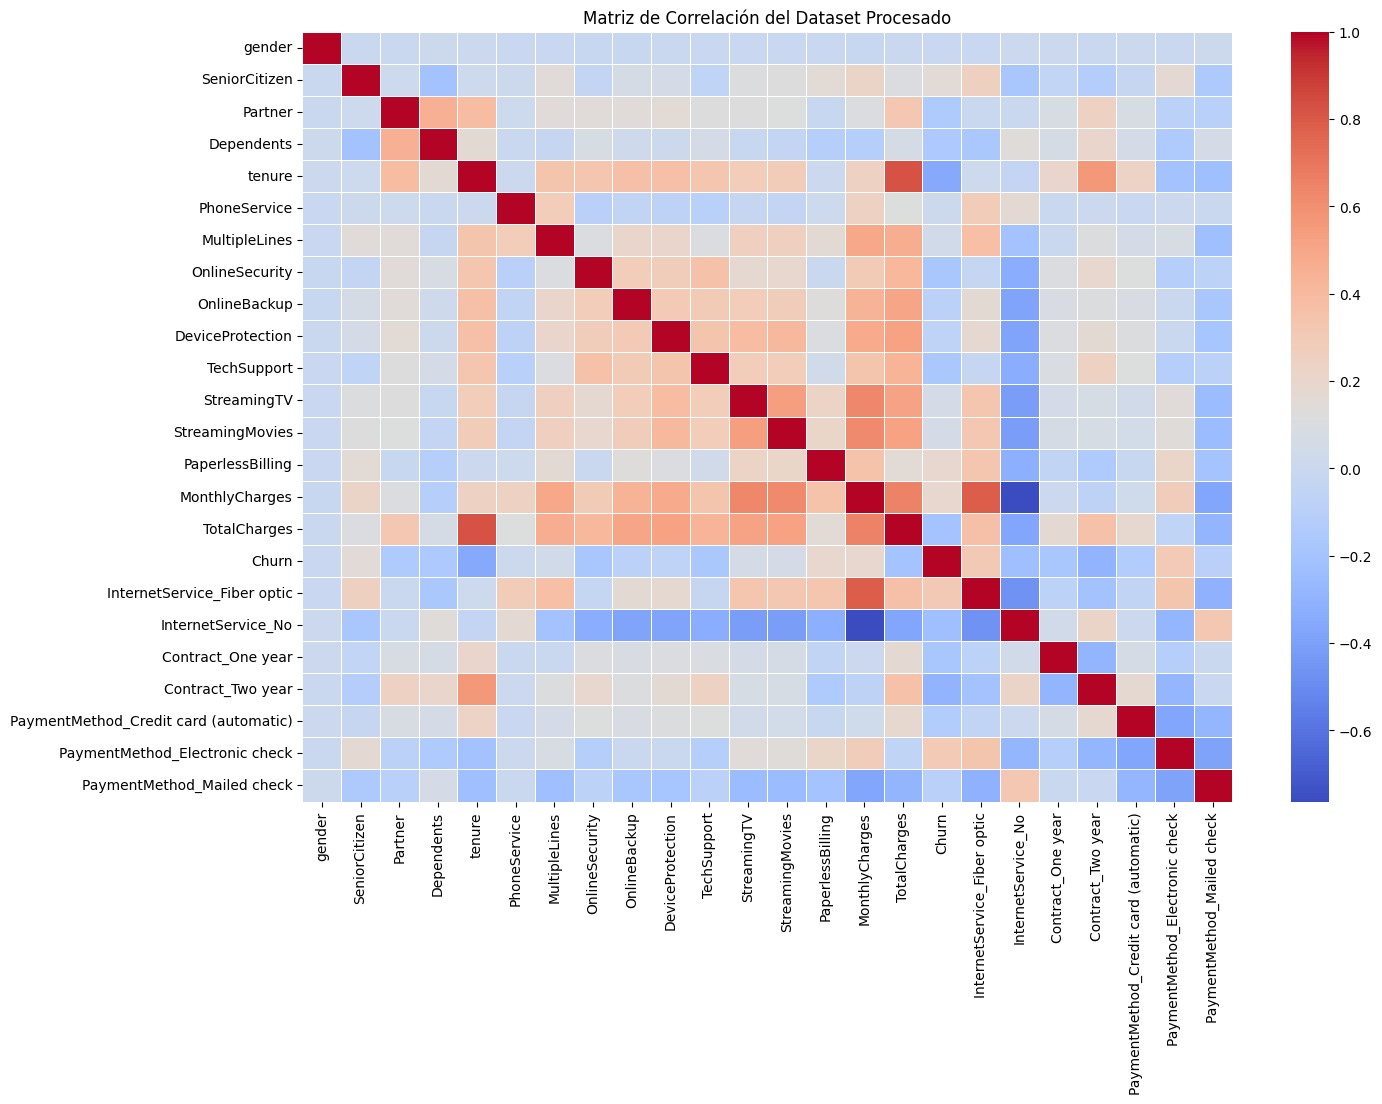

Correlación con la variable Churn:
Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
StreamingTV                              0.063254
StreamingMovies                          0.060860
MultipleLines                            0.040033
PhoneService                             0.011691
gender                                  -0.008545
DeviceProtection                        -0.066193
OnlineBackup                            -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner                                 -0.149982
Dependents                              -0.163128
TechSupport                             -0.164716
OnlineSecurity                          -0.171270
Contract_One ye

In [23]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(15, 10))

# Calcular la correlación
corr_matrix = df_proc.corr()

# Crear el mapa de calor
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación del Dataset Procesado')
plt.show()

# Ver específicamente la correlación con la variable objetivo
print("Correlación con la variable Churn:")
print(df_proc.corr()['Churn'].sort_values(ascending=False))

## SPLIT DE DATOS PROCESADOS

In [24]:
# Definimos la variable objetivo
y = df_proc['Churn']

# Definimos las características (todas menos Churn)
X = df_proc.drop('Churn', axis=1)

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Datos de entrenamiento: {X_train.shape[0]}")
print(f"Datos de prueba: {X_test.shape[0]}")

Datos de entrenamiento: 5625
Datos de prueba: 1407


Como vimos en los gráficos de outliers, tenemos variables con rangos muy distintos: tenure llega hasta $72$, mientras que los contratos son $0$ o $1$. Los modelos matemáticos funcionan mejor si todos los números están en una escala similar.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajustar el escalador solo con los datos de entrenamiento para evitar "fuga de información"
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## MODELADO

Intentaré primero con una: 
### Regresión Logística

### *Entrenamiento*

In [28]:
from sklearn.linear_model import LogisticRegression

# Crear e instanciar el modelo
model_lr = LogisticRegression()

In [29]:
# Entrenar con los datos de entrenamiento escalados
model_lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
# Realizar predicciones sobre el set de prueba
y_pred = model_lr.fit(X_train_scaled, y_train).predict(X_test_scaled)

### *Evaluación*
Reporte y Matriz de Confusión

In [31]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [32]:
# Mostrar métricas
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Exactitud (Accuracy): 0.8038379530916845

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



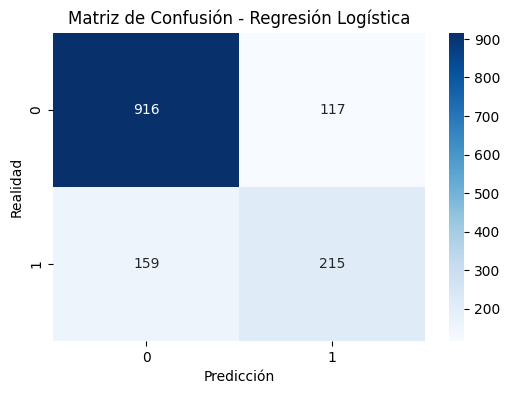

In [33]:
# Visualizar la Matriz de Confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

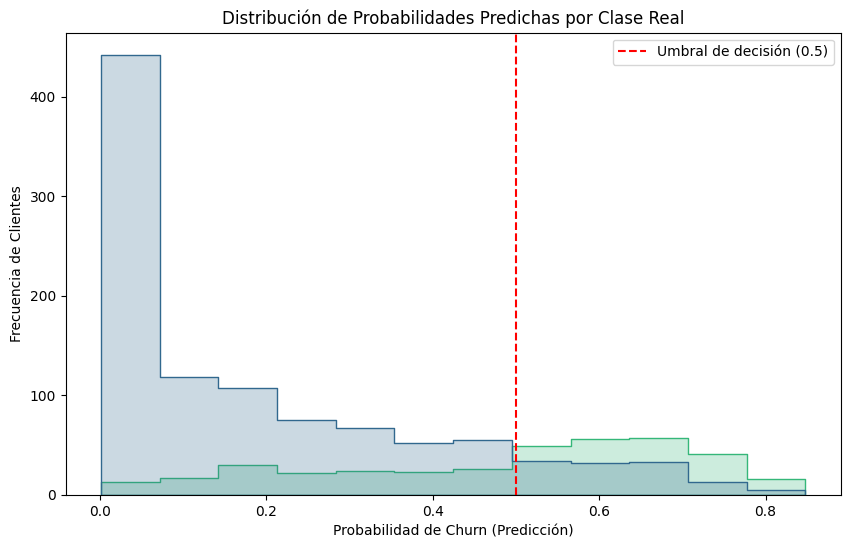

In [34]:
# Obtener las probabilidades de la clase 1 (Churn = Yes)
probabilities = model_lr.predict_proba(X_test_scaled)[:, 1]

# Crear el gráfico
plt.figure(figsize=(10, 6))
sns.histplot(x=probabilities, hue=y_test, element="step", common_norm=False, palette='viridis')
plt.title('Distribución de Probabilidades Predichas por Clase Real')
plt.xlabel('Probabilidad de Churn (Predicción)')
plt.ylabel('Frecuencia de Clientes')
plt.axvline(x=0.5, color='red', linestyle='--', label='Umbral de decisión (0.5)')
plt.legend()
plt.show()

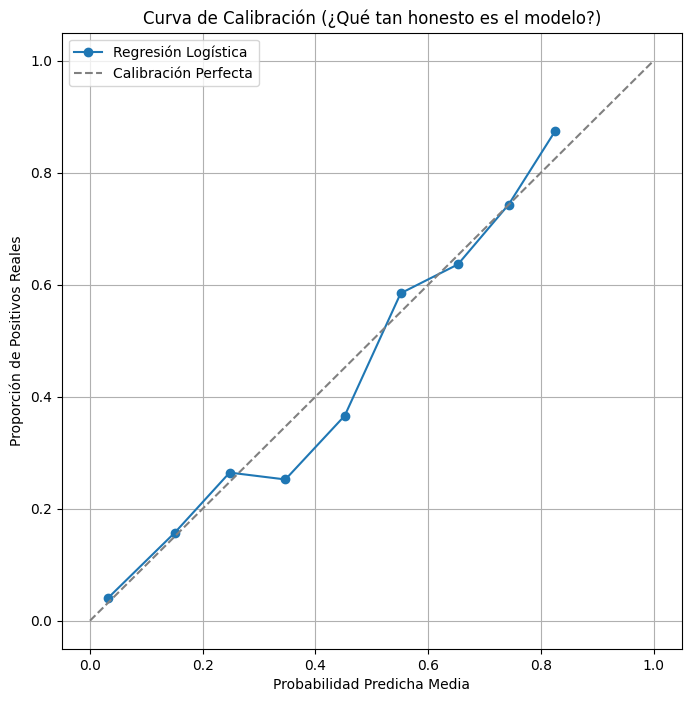

In [35]:
from sklearn.calibration import calibration_curve

# Calcular los puntos de la curva
prob_true, prob_pred = calibration_curve(y_test, probabilities, n_bins=10)

plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='o', label='Regresión Logística')
plt.plot([0, 1], [0, 1], linestyle='--', label='Calibración Perfecta', color='gray')
plt.xlabel('Probabilidad Predicha Media')
plt.ylabel('Proporción de Positivos Reales')
plt.title('Curva de Calibración (¿Qué tan honesto es el modelo?)')
plt.legend()
plt.grid(True)
plt.show()